In [2]:
import pandas as pd
accounts = pd.read_csv("C:/end to end projs/CRM sales/accounts.csv")
data_dict = pd.read_csv("C:/end to end projs/CRM sales/data_dictionary.csv")
products = pd.read_csv("C:/end to end projs/CRM sales/products.csv")
sales_pipeline = pd.read_csv("C:/end to end projs/CRM sales/sales_pipeline.csv")
sales_team = pd.read_csv("C:/end to end projs/CRM sales/sales_teams.csv")

In [3]:
accounts.isnull().sum()

account              0
sector               0
year_established     0
revenue              0
employees            0
office_location      0
subsidiary_of       70
dtype: int64

In [4]:
accounts["subsidiary_of"] = accounts["subsidiary_of"].fillna("Independent")

In [5]:
accounts.isnull().sum()

account             0
sector              0
year_established    0
revenue             0
employees           0
office_location     0
subsidiary_of       0
dtype: int64

In [6]:
products.isnull().sum()

product        0
series         0
sales_price    0
dtype: int64

In [7]:
sales_pipeline.isnull().sum()

opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value       2089
dtype: int64

In [8]:
sales_pipeline["account"] = sales_pipeline["account"].fillna("Unknown")

In [9]:
sales_pipeline["close_value"] = sales_pipeline["close_value"].fillna(0)

In [10]:
sales_pipeline["close_date"] = sales_pipeline["close_date"].ffill()

In [11]:
sales_pipeline["engage_date"] = sales_pipeline["engage_date"].ffill()

In [12]:
sales_pipeline.isnull().sum()

opportunity_id    0
sales_agent       0
product           0
account           0
deal_stage        0
engage_date       0
close_date        0
close_value       0
dtype: int64

In [13]:
sales_team.isnull().sum()

sales_agent        0
manager            0
regional_office    0
dtype: int64

In [14]:
sales_pipeline = sales_pipeline.drop_duplicates(subset = "opportunity_id")

In [15]:
accounts["sector"] = accounts["sector"].replace("technolgy", "technology")

accounts["subsidiary_of"] = accounts["subsidiary_of"].replace("lendependent", "Independent")

In [16]:
accounts.to_csv("accounts_clean.csv", index=False)
sales_pipeline.to_csv("sales_pipeline_clean.csv", index=False)
products.to_csv("products_clean.csv", index=False)
sales_team.to_csv("sales_teams_clean.csv", index=False)

In [17]:
sales_pipeline["close_value"].mean()

np.float64(1136.9925)

In [18]:
sales_pipeline.describe()

,close_value
count,8800.000000
mean,1136.992500
std,2123.528615
min,0.000000
25%,0.000000
50%,0.000000
75%,1085.250000
max,30288.000000


In [19]:
sales_pipeline.groupby("product")["close_value"].mean()

product
GTK 500           10015.300000
GTX Basic           267.557878
GTX Plus Basic      509.960231
GTX Plus Pro       2716.581612
GTXPro             2372.012162
MG Advanced        1569.679178
MG Special           26.509994
Name: close_value, dtype: float64

In [20]:
merged = sales_pipeline.merge(accounts, on="account")
merged[["employees","close_value"]].corr()

,employees,close_value
employees,1.000000,0.042687
close_value,0.042687,1.000000


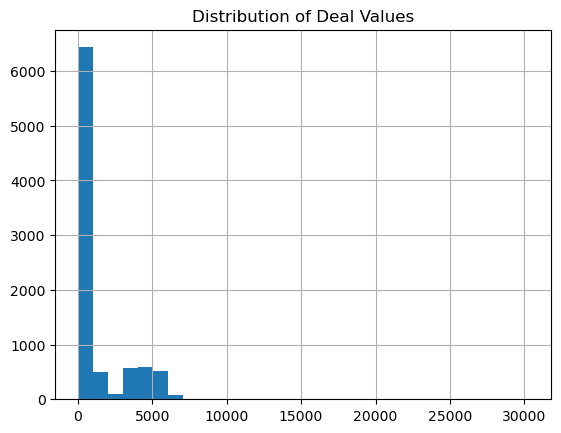

In [21]:
import matplotlib.pyplot as plt

sales_pipeline["close_value"].hist(bins=30)
plt.title("Distribution of Deal Values")
plt.show()

In [25]:
#TOTAL DEALS PER AGENT
total_deals = sales_pipeline.groupby("sales_agent")["opportunity_id"].count()
total_deals

sales_agent
Anna Snelling         448
Boris Faz             210
Cassey Cress          346
Cecily Lampkin        203
Corliss Cosme         310
Daniell Hammack       259
Darcel Schlecht       747
Donn Cantrell         275
Elease Gluck          177
Garret Kinder         123
Gladys Colclough      317
Hayden Neloms         202
James Ascencio        267
Jonathan Berthelot    345
Kami Bicknell         362
Kary Hendrixson       438
Lajuana Vencill       311
Markita Hansen        306
Marty Freudenburg     281
Maureen Marcano       285
Moses Frase           260
Niesha Huffines       239
Reed Clapper          237
Rosalina Dieter       160
Rosie Papadopoulos    160
Versie Hillebrand     361
Vicki Laflamme        451
Violet Mclelland      261
Wilburn Farren        110
Zane Levy             349
Name: opportunity_id, dtype: int64

In [26]:
#DEALS WON PER AGENT
won_deals = sales_pipeline[sales_pipeline["deal_stage"] == "Won"].groupby("sales_agent")["opportunity_id"].count()
won_deals

sales_agent
Anna Snelling         208
Boris Faz             101
Cassey Cress          163
Cecily Lampkin        107
Corliss Cosme         150
Daniell Hammack       114
Darcel Schlecht       349
Donn Cantrell         158
Elease Gluck           80
Garret Kinder          75
Gladys Colclough      135
Hayden Neloms         107
James Ascencio        135
Jonathan Berthelot    171
Kami Bicknell         174
Kary Hendrixson       209
Lajuana Vencill       127
Markita Hansen        130
Marty Freudenburg     122
Maureen Marcano       149
Moses Frase           129
Niesha Huffines       105
Reed Clapper          155
Rosalina Dieter        72
Rosie Papadopoulos     78
Versie Hillebrand     176
Vicki Laflamme        221
Violet Mclelland      122
Wilburn Farren         55
Zane Levy             161
Name: opportunity_id, dtype: int64

In [22]:
#CALCULATING WIN RATE
win_rate = (won_deals/total_deals) * 100
win_rate

sales_agent
Anna Snelling         46.428571
Boris Faz             48.095238
Cassey Cress          47.109827
Cecily Lampkin        52.709360
Corliss Cosme         48.387097
Daniell Hammack       44.015444
Darcel Schlecht       46.720214
Donn Cantrell         57.454545
Elease Gluck          45.197740
Garret Kinder         60.975610
Gladys Colclough      42.586751
Hayden Neloms         52.970297
James Ascencio        50.561798
Jonathan Berthelot    49.565217
Kami Bicknell         48.066298
Kary Hendrixson       47.716895
Lajuana Vencill       40.836013
Markita Hansen        42.483660
Marty Freudenburg     43.416370
Maureen Marcano       52.280702
Moses Frase           49.615385
Niesha Huffines       43.933054
Reed Clapper          65.400844
Rosalina Dieter       45.000000
Rosie Papadopoulos    48.750000
Versie Hillebrand     48.753463
Vicki Laflamme        49.002217
Violet Mclelland      46.743295
Wilburn Farren        50.000000
Zane Levy             46.131805
Name: opportunity_id, dtype:

In [30]:
#CREATING WIN_RATE COLUMN AND TABLE
total_deals = sales_pipeline.groupby("sales_agent")["opportunity_id"].count()

won_deals = sales_pipeline[sales_pipeline["deal_stage"] == "Won"].groupby("sales_agent")["opportunity_id"].count()

win_rate = (won_deals / total_deals) * 100

win_rate = win_rate.reset_index()

win_rate.columns = ["sales_agent", "win_rate"]

win_rate.head()

,sales_agent,win_rate
0,Anna Snelling,46.428571
1,Boris Faz,48.095238
2,Cassey Cress,47.109827
3,Cecily Lampkin,52.709360
4,Corliss Cosme,48.387097


In [24]:
#MERGING WITH SALES_TEAMS TABLE
win_rate = win_rate.merge(sales_team,on="sales_agent")

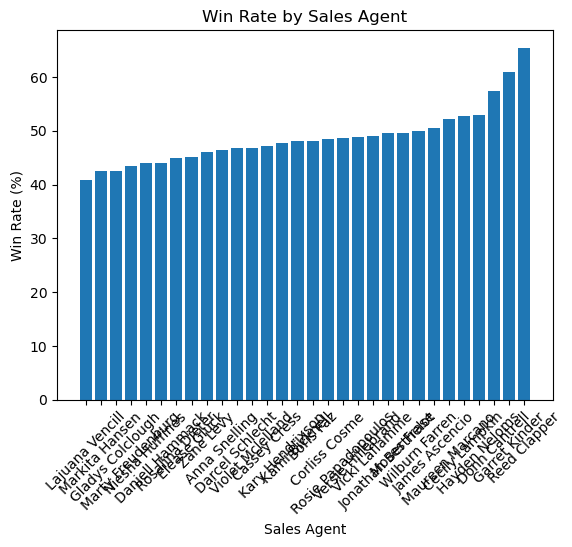

In [25]:
import matplotlib.pyplot as plt

win_rate_sorted = win_rate.sort_values("win_rate")

plt.figure()

plt.bar(win_rate_sorted["sales_agent"], win_rate_sorted["win_rate"])

plt.title("Win Rate by Sales Agent")
plt.xlabel("Sales Agent")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [26]:
win_rate.head()

,sales_agent,win_rate,manager,regional_office
0,Anna Snelling,46.428571,Dustin Brinkmann,Central
1,Boris Faz,48.095238,Rocco Neubert,East
2,Cassey Cress,47.109827,Rocco Neubert,East
3,Cecily Lampkin,52.709360,Dustin Brinkmann,Central
4,Corliss Cosme,48.387097,Cara Losch,East


In [27]:
win_rate.dtypes

sales_agent         object
win_rate           float64
manager             object
regional_office     object
dtype: object

In [32]:
#SALES FUNNEL COVERSION RATE
funnel = sales_pipeline["deal_stage"].value_counts()
funnel

deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64

In [34]:
won = sales_pipeline[sales_pipeline["deal_stage"] == "Won"].shape[0]
total = sales_pipeline.shape[0]

conversion_rate = (won/total) * 100

conversion_rate

48.15909090909091

In [ ]:
# the overall sales coversion_rate is 48% so roughly 1 in 2 opprotunities becomes a closed deal

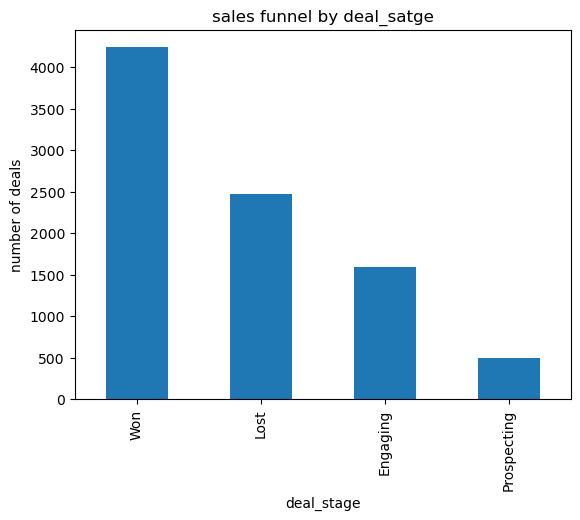

In [36]:
import matplotlib.pyplot as plt
funnel.plot(kind="bar")

plt.title("sales funnel by deal_satge")
plt.xlabel("deal_stage")
plt.ylabel("number of deals")

plt.show()


In [44]:
#AVERAGE SALES CYCLE LENGTH
sales_pipeline["engage_date"] = pd.to_datetime(sales_pipeline["engage_date"])
sales_pipeline["close_date"] = pd.to_datetime(sales_pipeline["close_date"])

In [45]:
sales_pipeline["sales_cycle_days"] = (sales_pipeline["close_date"] - sales_pipeline["engage_date"]).dt.days

In [46]:
sales_pipeline["sales_cycle_days"].mean()

np.float64(45.80386363636364)

In [ ]:
#on average it takes 45 days to close a deal